# 1 — Predicting multiplex immunofluorescence from H&E

In this tutorial, we use 3 QUEST models for predicting MIF intensity maps from
H&E alone.

What the tutorial covers:

1. Load models and example case.

2. Predicting workflow with arbitrary combination of markers.

3. Pixel- and grid-level metrics with Pearson Correlation Coefficient and Spearman's $\rho$.

Data: **stanford-pc** (`data/stanford-pc`, pancreas patches) — see [Tutorial 0](./00_data.ipynb).

In [1]:
import _common  # path setting
import numpy as np
import matplotlib.pyplot as plt

from quest import QuestGenerator
from questkit import cohort
import time
from questkit.predict_mif import fidelity, case_figure

rows = cohort.stanford_pc_index("Pancreas")
panel_all = cohort.common_panel(rows)
print(f"{len(rows)} patches from {len({r['region_id'] for r in rows})} regions")
print(f"{len(panel_all)} markers measured in every patch:\n{panel_all}")


326 patches from 29 regions
41 markers measured in every patch:
['ATM', 'BCL2', 'CD11c', 'CD141', 'CD163', 'CD20', 'CD21', 'CD31', 'CD38', 'CD39', 'CD3e', 'CD4', 'CD45', 'CD45RO', 'CD66', 'CD68', 'CD79', 'CD8', 'Caveolin1', 'CollagenIV', 'DAPI', 'ECad', 'ERa', 'EpCAM', 'FoxP3', 'Gal3', 'HLA-ABC', 'HLA-DR', 'HLA-E', 'ICOS', 'IDO1', 'IFNg', 'Keratin8/18', 'Ki67', 'LAG3', 'MPO', 'PCNA', 'PD1', 'PDL1', 'TIGIT', 'TP63']


In [2]:
# load a single patch for prediction and visualization
CASE = "Charvill-94_c003_v001_r001_reg122_5"
PANEL = ["DAPI", "EpCAM", "ECad", "CD31", "CD20", "CD68", "CD3e", "CD8"]

case = cohort.load_patch(next(r for r in rows if r["stem"] == CASE))
real = np.stack([[case.marker(m) for m in PANEL]])          # (1, 8, 224, 224)

# the two filters, reasonable tissue coverage and signal intensity.
tissue = cohort.tissue_fraction(case.he)
present = {m: float((case.marker(m) > 0.15).mean()) for m in PANEL}
assert tissue >= 0.95, f"only {tissue:.0%} tissue"
assert min(present.values()) > 0.02, f"barely stained: {min(present, key=present.get)}"
print(f"{case.region_id} / {case.stem}")
print(f"  tissue coverage {tissue:.0%}")
print("  positive-pixel fraction: " + "  ".join(f"{m} {f:.2f}" for m, f in present.items()))

Charvill-94_c003_v001_r001_reg122 / Charvill-94_c003_v001_r001_reg122_5
  tissue coverage 95%
  positive-pixel fraction: DAPI 0.36  EpCAM 0.47  ECad 0.39  CD31 0.06  CD20 0.28  CD68 0.18  CD3e 0.03  CD8 0.09


In [3]:
# generate staining outputs with different models
arms = []
for name, label in [("quest-semantic", "QUEST-semantic"), ("quest-id", "QUEST-id"), ("quest-eva", "QUEST-EVA")]:
    t = time.time()
    stainer = QuestGenerator(name, device=_common.DEVICE)
    p = stainer(case.he[None, ...], PANEL)
    arms.append((label, p[0], fidelity(p, real, PANEL, grid_sizes=(16,))))
    print(f"Time taken for {name} loading and inference : {time.time() - t:.2f} seconds")
    del stainer

Time taken for quest-semantic loading and inference : 11.70 seconds


Time taken for quest-id loading and inference : 10.00 seconds


Time taken for quest-eva loading and inference : 1.46 seconds


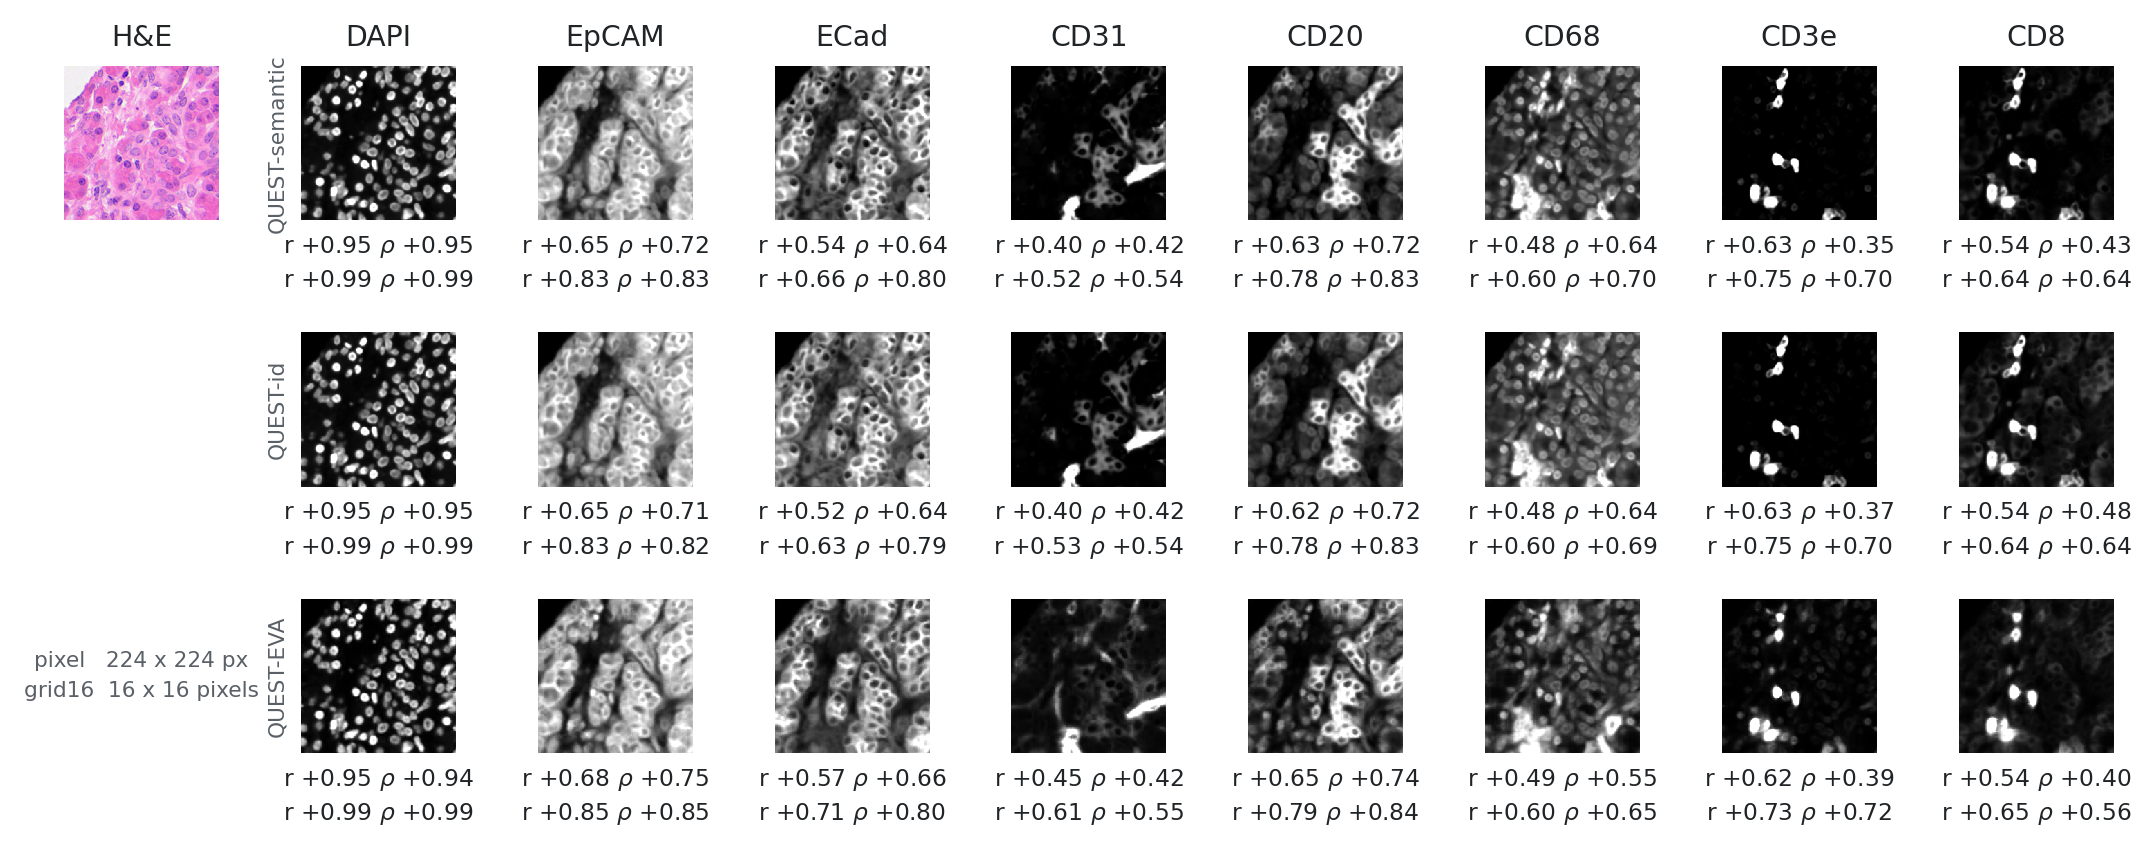

In [4]:
fig = case_figure(case.he, arms, PANEL)
plt.show()